## Model: Triển khai so sánh Mô hình Naive Forecast với mô hình ARIMA/SARIMA
### (Daily Forecasting + MAE Evaluation)

In [2]:
# import package
import pandas as pd 
import numpy as np
import sktime ## sktime 0.40.1

# Statistical Models
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime
from pandas import Series
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error  ##sklearn<1.6.0 = 1.5.2

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

In [3]:
data = pd.read_csv('./data/Ferrari History Stock Data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2598 non-null   object 
 1   Close   2598 non-null   float64
 2   High    2598 non-null   float64
 3   Low     2598 non-null   float64
 4   Open    2598 non-null   float64
 5   Volume  2598 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 121.9+ KB


In [4]:
dt = data.copy()
dt['Date'] = pd.to_datetime(dt['Date'])

#### ARIMA (Daily Forecasting)

In [5]:
# reindex về daily, forward-fill các ngày cuối tuần / ngày nghỉ
daily_close = dt.set_index('Date')['Close'].resample('B').ffill() 

print(f"Số điểm du liệu: {len(daily_close)}")
print(f"Từ: {daily_close.index[0].date()} đến {daily_close.index[-1].date()}")
daily_close.tail()

Số điểm du liệu: 2698
Từ: 2015-10-21 đến 2026-02-20


Date
2026-02-16    379.079987
2026-02-17    374.989990
2026-02-18    366.429993
2026-02-19    366.500000
2026-02-20    366.950012
Freq: B, Name: Close, dtype: float64

In [7]:
from statsmodels.tsa.stattools import adfuller

# giữ lại 30 ngày cuối để đánh giá MAE
TEST_DAYS = 30
train_series = daily_close.iloc[:-TEST_DAYS]
test_series  = daily_close.iloc[-TEST_DAYS:]

print(f"Train: {len(train_series)} điểm | Test: {len(test_series)} điểm")

# kiểm tra tính dừng và sai phân bậc 1
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    return result[1] <= 0.05

is_stationary = adf_test(train_series)
print(f"Chuỗi dừng (p<=0.05): {is_stationary}")

if not is_stationary:
    diff = train_series.diff().dropna()
    is_diff_stationary = adf_test(diff)
    print(f"Sau sai phân bậc 1 - Dừng: {is_diff_stationary}")

Train: 2668 điểm | Test: 30 điểm
Chuỗi dừng (p<=0.05): False
Sau sai phân bậc 1 - Dừng: True


In [ ]:
# Auto ARIMA 
from pmdarima import auto_arima

# dùng dữ liệu train (daily)
auto_model = auto_arima(train_series,
                        seasonal=False,
                        stepwise=True,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        max_p=5,
                        max_d=2,
                        max_q=5)

print("\n=== AUTO ARIMA RESULTS ===")
print(f"Best ARIMA order (auto): {auto_model.order}")
print("\nModel Summary:")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=15557.755, Time=3.48 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15562.812, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15563.715, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=15563.723, Time=0.46 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15562.795, Time=0.23 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=15567.000, Time=1.41 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=15567.008, Time=2.98 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=15560.148, Time=3.84 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=15560.097, Time=3.21 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=15565.067, Time=1.02 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=15565.499, Time=1.88 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=15566.114, Time=0.69 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=15553.963, Time=7.52 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=15547.927, Time=6.70 sec
 ARIMA(4,1,2)(0,0,0

In [ ]:
auto_best_order = auto_model.order
auto_best_aic   = auto_model.aic

print(f"Auto ARIMA best order: {auto_best_order}, AIC: {auto_best_aic}")

Auto ARIMA best order: (4, 1, 5), AIC: <bound method ARIMA.aic of ARIMA(order=(4, 1, 5), scoring_args={}, suppress_warnings=True,
      with_intercept=False)>


In [ ]:
# Grid search ARIMA (p, d, q) trên tập TRAIN
p_values = range(0, 5)
d_values = range(0, 2)
q_values = range(0, 5)
best_aic   = float('inf')
best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p, d, q)
            try:
                model_tmp = ARIMA(train_series, order=order)
                fit_tmp   = model_tmp.fit()
                if fit_tmp.aic < best_aic:
                    best_aic   = fit_tmp.aic
                    best_order = order
            except:
                continue

print(f"Grid-search best order: {best_order}, AIC: {best_aic:.4f}")

Grid-search best order: (3, 1, 3), AIC: 15547.0386


Đưa dữ liệu vào model (train)

In [ ]:
model     = ARIMA(train_series, order=best_order)
model_fit = model.fit()

print(f"Sử dụng tham số: {best_order}")
print(model_fit.summary())

Sử dụng tham số: (3, 1, 3)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2668
Model:                 ARIMA(3, 1, 3)   Log Likelihood               -7766.519
Date:                Sun, 24 May 2026   AIC                          15547.039
Time:                        09:30:39   BIC                          15588.260
Sample:                    10-21-2015   HQIC                         15561.955
                         - 01-09-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0279      0.050      0.559      0.576      -0.070       0.126
ar.L2         -0.0431      0.049     -0.878      0.380      -0.139       0.053
ar.L3         -0.7787    

Đưa ra dự đoán cho 30 ngày tiếp theo - Daily Time Forecasting + MAE Evaluation

In [ ]:
# dự báo 30 ngày tiếp theo(out-of-sample)
forecast_steps = TEST_DAYS
forecast_values = model_fit.forecast(steps=forecast_steps)

# gán đúng DatetimeIndex (business days)
last_train_date = train_series.index[-1]
forecast_index  = pd.bdate_range(start=last_train_date + pd.Timedelta(days=1), periods=forecast_steps)
forecast_series = pd.Series(forecast_values.values, index=forecast_index[:len(forecast_values)])

# MAE
# 1. MAE out-of-sample (forecast vs actual test set)
mae_oos = mean_absolute_error(test_series.values[:len(forecast_series)], forecast_series.values)

# 2. MAE in-sample (fitted vs train)
fitted_values = model_fit.fittedvalues
mae_in  = mean_absolute_error(train_series.values, fitted_values.values)

# 3. MAPE out-of-sample
mape_oos = mean_absolute_percentage_error(test_series.values[:len(forecast_series)], forecast_series.values)

print("=" * 45)
print(f"  MAE  (in-sample  / train) : {mae_in:.4f}")
print(f"  MAE  (out-of-sample / test): {mae_oos:.4f}")
print(f"  MAPE (out-of-sample / test): {mape_oos*100:.2f}%")
print("=" * 45)
forecast_series

  MAE  (in-sample  / train) : 2.6104
  MAE  (out-of-sample / test): 26.2360
  MAPE (out-of-sample / test): 7.68%


2026-01-12    375.902125
2026-01-13    375.661730
2026-01-14    376.041236
2026-01-15    376.286350
2026-01-16    376.464040
2026-01-19    376.162899
2026-01-20    375.955971
2026-01-21    375.824800
2026-01-22    376.064568
2026-01-23    376.238045
2026-01-26    376.334700
2026-01-27    376.143204
2026-01-28    375.998610
2026-01-29    375.927559
2026-01-30    376.080933
2026-02-02    376.200869
2026-02-03    376.252936
2026-02-04    376.129783
2026-02-05    376.030708
2026-02-06    375.992705
2026-02-09    376.091818
2026-02-10    376.173371
2026-02-11    376.200969
2026-02-12    376.121043
2026-02-13    376.054117
2026-02-16    376.034203
2026-02-17    376.098772
2026-02-18    376.153547
2026-02-19    376.167801
2026-02-20    376.115556
Freq: B, dtype: float64

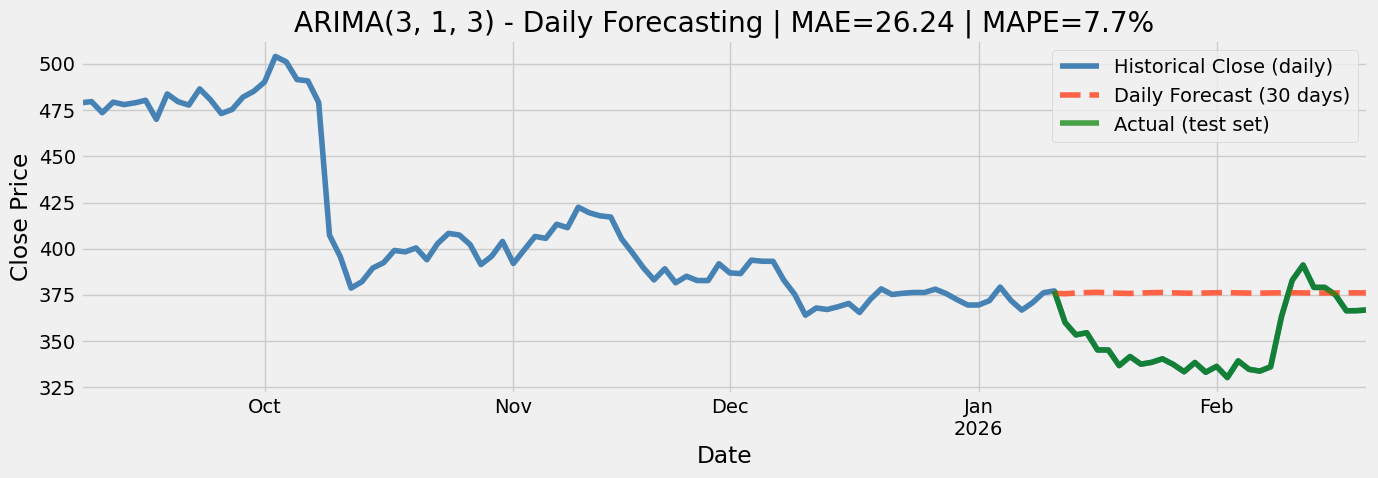

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# chỉ vẽ 120 ngày cuối
daily_close.iloc[-120:].plot(ax=ax, label='Historical Close (daily)', legend=True, color='steelblue')
forecast_series.plot(ax=ax, label='Daily Forecast (30 days)', legend=True, color='tomato', linestyle='--')

# Vẽ thêm actual test để so sánh trực quan
test_series.plot(ax=ax, label='Actual (test set)', legend=True, color='green', alpha=0.7)

ax.set_title(f'ARIMA{best_order} - Daily Forecasting | MAE={mae_oos:.2f} | MAPE={mape_oos*100:.1f}%')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Dữ liệu ngày (train tail):")
daily_close.tail(10)

Dữ liệu ngày (train tail):


Date
2026-02-09    336.130005
2026-02-10    363.220001
2026-02-11    382.959991
2026-02-12    391.209991
2026-02-13    379.079987
2026-02-16    379.079987
2026-02-17    374.989990
2026-02-18    366.429993
2026-02-19    366.500000
2026-02-20    366.950012
Freq: B, Name: Close, dtype: float64

Với dữ liệu Ngày (~2600 điểm), ARIMA có đủ dữ liệu để hội tụ tốt hơn so với dữ liệu Quý (~40–50 điểm).

- **MAE in-sample**: đo mức sai lệch trung bình tuyệt đối trên tập huấn luyện.
- **MAE out-of-sample**: đo sai lệch thực tế của forecast so với 30 ngày cuối (test set).
- **MAPE**: phần trăm sai lệch — dễ so sánh giữa các mô hình.

--> Tiếp theo có thể dùng **SARIMA** nếu dữ liệu ngày có tính mùa vụ rõ ràng (seasonality theo tuần, tháng).